In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/ml_dataset/train.csv")
meal = pd.read_csv("/content/drive/MyDrive/ml_dataset/meal_info.csv")
center = pd.read_csv("/content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/train.csv")
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/meal_info.csv")
df.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv")
df.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [ ]:
#X = df[['Annual Income(k$)', 'Spending Score(1-1000)]]
X = df.iloc[:,[3,4]].values

In [ ]:
print(X)

[['TYPE_A' 3.7]
 ['TYPE_B' 6.7]
 ['TYPE_C' 4.0]
 ['TYPE_A' 4.1]
 ['TYPE_C' 3.6]
 ['TYPE_A' 4.4]
 ['TYPE_A' 3.9]
 ['TYPE_C' 2.8]
 ['TYPE_A' 4.1]
 ['TYPE_B' 3.8]
 ['TYPE_C' 2.8]
 ['TYPE_C' 4.0]
 ['TYPE_A' 3.8]
 ['TYPE_A' 2.4]
 ['TYPE_B' 4.0]
 ['TYPE_C' 2.9]
 ['TYPE_A' 4.5]
 ['TYPE_C' 2.7]
 ['TYPE_C' 3.0]
 ['TYPE_A' 4.5]
 ['TYPE_A' 3.8]
 ['TYPE_A' 3.4]
 ['TYPE_A' 4.6]
 ['TYPE_B' 5.0]
 ['TYPE_C' 4.0]
 ['TYPE_A' 3.9]
 ['TYPE_C' 5.1]
 ['TYPE_C' 2.0]
 ['TYPE_A' 3.4]
 ['TYPE_A' 4.5]
 ['TYPE_C' 0.9]
 ['TYPE_A' 4.0]
 ['TYPE_A' 4.0]
 ['TYPE_A' 4.0]
 ['TYPE_A' 4.0]
 ['TYPE_C' 4.0]
 ['TYPE_A' 5.1]
 ['TYPE_A' 2.8]
 ['TYPE_A' 4.5]
 ['TYPE_A' 4.8]
 ['TYPE_A' 5.3]
 ['TYPE_C' 2.8]
 ['TYPE_A' 2.7]
 ['TYPE_A' 3.4]
 ['TYPE_B' 7.0]
 ['TYPE_A' 7.0]
 ['TYPE_A' 4.2]
 ['TYPE_C' 3.8]
 ['TYPE_A' 4.8]
 ['TYPE_C' 3.8]
 ['TYPE_A' 3.9]
 ['TYPE_A' 4.8]
 ['TYPE_C' 2.0]
 ['TYPE_B' 4.7]
 ['TYPE_C' 3.9]
 ['TYPE_C' 1.9]
 ['TYPE_B' 6.3]
 ['TYPE_A' 3.8]
 ['TYPE_B' 5.6]
 ['TYPE_A' 3.9]
 ['TYPE_A' 2.8]
 ['TYPE_B' 4.2]
 ['TYPE_

In [ ]:
import pandas as pd

In [ ]:
data = train.merge(meal, on="meal_id")
data = data.merge(center, on="center_id")

In [ ]:
data['demand'] = data['num_orders'].apply(lambda x: 1 if x > 100 else 0)
data = data.drop(['num_orders'], axis=1)
data = pd.get_dummies(data)


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[14609535.999999786, 13205549.616810022, 12189062.4245231, 11262454.291524976, 10905678.801488537, 10409298.573224636, 9674085.766808294, 9532064.98466469, 8904153.866926217, 8398643.962761996]


Text(0.5, 1.0, 'Elbow Method for Optimal K')

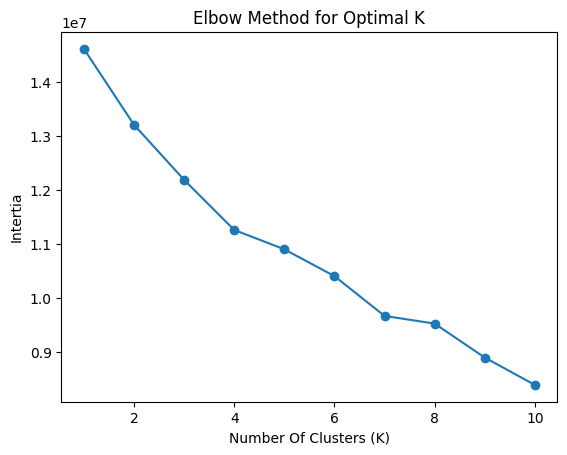

In [ ]:
from sklearn.cluster import KMeans
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
plt.figure()
plt.plot(range(1,11),inertia_values, marker='o')
plt.xlabel("Number Of Clusters (K)")
plt.ylabel("Intertia")
plt.title("Elbow Method for Optimal K")


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['cluster'] = clusters
print(data.head())

        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  city_code  region_code  ...  \
0                      0                  0        647           56  ...   
1                      0                  0        647           56  ...   
2                      0                  0        647           56  ...   
3                      0                  0        647           56  ...   
4                      0                  0        647           56  ...   

   category_Soup  category_Starters  cuisine_Continental  cuisine_Indian  \
0          False              False                False  

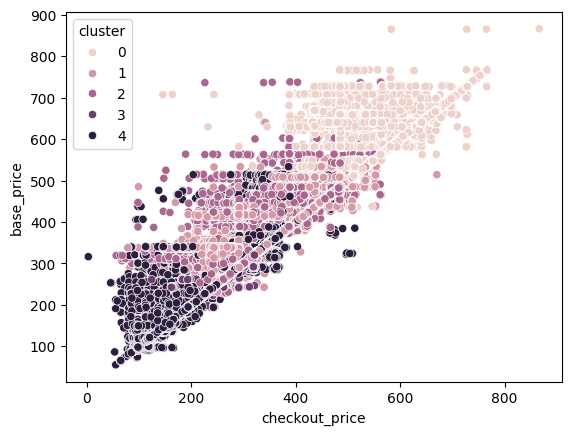

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='checkout_price', y='base_price', hue='cluster', data=data)
plt.show()

In [ ]:
#Prediction
y_pred = knn.predict(X_test)

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))